In [1]:
import json
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 

In [2]:
def aggregate_balrog_results(root_directory):
    """
    Walks through a Hydra multirun directory structure to aggregate BALROG results.
    Prints a Markdown table sorted by Output Tokens (descending).
    """
    
    # Stores raw values: {'plan_every_2': {'progression_percentage': [], ...}}
    raw_data = defaultdict(lambda: {"progression_percentage": [], "standard_error": [], "output_tokens": [], "average_steps": []})
    
    # Store metadata mapping (Planning Key -> Model Name)
    key_metadata = {}

    print(f"Scanning {root_directory}...")
    
    for root, dirs, files in os.walk(root_directory):
        if "summary.json" in files:
            
            # 1. READ CONFIG
            try:
                with open(os.path.join(root, "summary.json"), 'r') as f:
                    summary_conf = json.load(f)
                
                agent_conf = summary_conf.get("agent", {})
                client_conf = summary_conf.get("client", {})
                agent_type = agent_conf.get("type", "")
                
                # Try to find model name, default to what you provided if missing
                # Adjust the path ["model"]["name"] based on your actual config structure
                model_name = client_conf.get("model_id", "Llama-3.3-70B")
                if "/" in model_name: 
                    model_name = model_name.split("/")[-1] # Clean up paths if necessary

                # Map the config to your desired keys
                if agent_type == "never_plan":
                    key_name = "never_plan"
                elif agent_type == "always_plan":
                    key_name = "always_plan"
                elif "plan_every" in agent_type:
                    k = agent_conf.get("plan_k")
                    if k is not None:
                        key_name = f"plan_every_{k}"
                    else:
                        continue
                else:
                    continue
                
                # Store metadata for this key
                key_metadata[key_name] = model_name

            except Exception as e:
                print(f"Error reading summary at {root}: {e}")
                continue

            # 2. FIND DATA
            game_metrics = None
            for d in dirs:
                game_summary_path = os.path.join(root, d, f"{d}_summary.json")
                if os.path.exists(game_summary_path):
                    try:
                        with open(game_summary_path, 'r') as f:
                            game_metrics = json.load(f)
                        break 
                    except Exception as e:
                        continue
            
            # 3. AGGREGATE
            if game_metrics:
                for metric in ["progression_percentage", "standard_error", "output_tokens", "average_steps"]:
                    if metric in game_metrics:
                        val = game_metrics[metric]
                        if isinstance(val, list):
                            raw_data[key_name][metric].extend(val)
                        else:
                            raw_data[key_name][metric].append(val)

    # 4. CALCULATE STATISTICS & PREPARE TABLE ROWS
    table_rows = []
    final_data_dict = {} # Keeping this if you need the return value programmatically

    for key, metrics in raw_data.items():
        final_data_dict[key] = {}
        
        # Calculate means
        results = {}
        for metric_name, values in metrics.items():
            if not values:
                results[metric_name] = (0.0, 0.0)
                continue
            arr = np.array(values)
            mean_val = float(np.mean(arr))
            stderr_val = float(np.std(arr) / np.sqrt(len(arr)))
            results[metric_name] = (mean_val, stderr_val)
        
        final_data_dict[key] = results
        
        # --- Formatting for Table ---
        
        # 1. Method (Hardcoded as per instructions)
        method_str = "Zero-shot"
        
        # 2. Model
        model_str = key_metadata.get(key, "Unknown-Model")
        
        # 3. Planning String
        if key == "never_plan":
            plan_str = "Never"
        elif key == "always_plan":
            plan_str = "Always (Every step)"
        elif key.startswith("plan_every_"):
            k_val = key.split("_")[-1]
            plan_str = f"Every {k_val} steps"
        else:
            plan_str = key
            
        # 4. Progression (Mean ± SE)
        p_mean, _ = results["progression_percentage"]
        p_err, _ = results["standard_error"]
        # If stderr is 0, you might optionally omit it, but here we keep the format
        progression_str = f"{p_mean:.3f} ± {p_err:.3f}"
        
        # 5. Tokens (Mean)
        t_mean, _ = results["output_tokens"]
        
        # Store for sorting
        table_rows.append({
            "method": method_str,
            "model": model_str,
            "planning": plan_str,
            "progression": progression_str,
            "token_sort_val": t_mean, # specific key for sorting
            "token_display": f"{t_mean:.1f}"
        })

    # 5. SORT AND PRINT
    # Sort descending by average output tokens
    table_rows.sort(key=lambda x: x["token_sort_val"], reverse=True)

    print("\n### Aggregated Results Table")
    print("| Method | Model | Planning | Progression | Avg. Output Tokens |")
    print("| :--- | :--- | :--- | :--- | :--- |")
    
    for row in table_rows:
        print(f"| {row['method']} | {row['model']} | {row['planning']} | {row['progression']} | {row['token_display']} |")

    print("\n")
    return final_data_dict

In [3]:
data_dict = aggregate_balrog_results("/home/bartek_sakana_ai/BALROG/multirun/llama8b_textworld")

Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_textworld...



### Aggregated Results Table
| Method | Model | Planning | Progression | Avg. Output Tokens |
| :--- | :--- | :--- | :--- | :--- |
| Zero-shot | Llama-3.1-8B-Instruct | Always (Every step) | 0.416 ± 0.210 | 1700531.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 2 steps | 1.426 ± 0.386 | 723546.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 3 steps | 2.258 ± 0.574 | 477424.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 4 steps | 2.761 ± 0.675 | 348374.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 6 steps | 3.268 ± 0.789 | 243647.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 8 steps | 4.219 ± 1.277 | 172787.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 12 steps | 3.506 ± 0.943 | 127463.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 16 steps | 3.803 ± 0.956 | 87706.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 24 steps | 4.397 ± 1.084 | 72446.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Never | 3.803 ± 0.906 | 23601.0 |




In [4]:
def make_a_plot(root_dir):
    data_dict = aggregate_balrog_results(root_dir)
    name = Path(root_dir).stem

    # Apply a style for a more academic look, and set a common sans-serif font.
    # plt.style.use('seaborn-v0_8-paper') # 'seaborn-v0_8-paper' or 'seaborn-v0_8-ticks' can be good base
    plt.rcParams['font.family'] = 'sans-serif'
    # Common choices: 'Arial', 'Helvetica', 'DejaVu Sans' (default)
    # If 'Arial' or 'Helvetica' are not available, Matplotlib will fall back.
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    plt.rcParams['axes.titlesize'] = 28 # Title font size
    plt.rcParams['axes.labelsize'] = 24 # Axis label font size
    plt.rcParams['xtick.labelsize'] = 18  # X-tick label font size
    plt.rcParams['ytick.labelsize'] = 18 # Y-tick label font size
    plt.rcParams['legend.fontsize'] = 15 # Legend font size
    plt.rcParams['lines.linewidth'] = 2.0 # Default line width for plots

    # Common styling for all subplots
    def style_subplot(ax):
        ax.grid(True, color='lightgray', linestyle='-', linewidth=0.7, alpha=0.7)
        ax.tick_params(direction='out', length=0, width=0, colors='black')  # Turn off ticks
        for spine in ax.spines.values():
            spine.set_visible(False)  # Hide all spines (no edgecolor)

    # Extract data for plotting
    labels = []
    x_values = []
    y_values = []
    y_errors = []


    names = {
        "never_plan": "never",
        "always_plan": "always",
        "plan_every_2": "2",
        "plan_every_3": "3",     
        "plan_every_4": "4",
        "plan_every_6": "6",
        "plan_every_8": "8",
        "plan_every_12": "12",
        "plan_every_16": "16",
        "plan_every_24": "24",
    }


    for key, data in data_dict.items():
        if data["progression_percentage"] and data["output_tokens"]: # Ensure data was loaded
            # labels.append(key.replace("plan_every_", "").replace("_plan", "")) # Simplify labels
            labels.append(names[key]) # Simplify labels
            # Use the original mean output tokens for X axis
            mean_tokens, _ = data["output_tokens"]
            x_values.append(mean_tokens)

            # Use mean progression for Y axis and its std error for error bars
            mean_prog, _ = data["progression_percentage"]
            std_err_prog, _ = data["standard_error"]
            y_values.append(mean_prog)
            y_errors.append(std_err_prog)

    # Create figure and axes
    fig, axes = plt.subplots(1, 1, figsize=(10, 6), dpi=300) # Adjusted figsize for typical paper width
    fig.patch.set_alpha(0.0)
    axes.patch.set_alpha(0.0) 
    # axes = [axes] # Wrap in a list for consistent handling

    # Plot original x values, but set the scale to log
    axes.errorbar(x_values, y_values, yerr=y_errors, fmt='o', capsize=5, color="black", ecolor="dimgrey")

    # Set x-axis to log scale (base 10)
    axes.set_xscale('log', base=10)

    # Add labels to each point
    for i, label in enumerate(labels):
        axes.annotate(label, (x_values[i], y_values[i]), textcoords="offset points", fontsize=24, xytext=(0, 10), ha='center', color="black")

    # axes.set_xticks([x_values[i] for i in range(len(labels))]) 
    # axes.set_xticklabels(labels, rotation=0, ha='center', size=24)

    # Add plot labels and title
    axes.set_xlabel("Output Tokens (Log Scale)")
    axes.set_ylabel("Progression")
    # axes.set_xlim(0, 5.4*10**4) # Set y-axis limits
    # axes.set_title("Performance vs. Cost for Different Planning Frequencies")
    axes.set_title(name, y=1.05) # Adjust title position
    axes.grid(True, which="both", ls="--") # Add grid for both major and minor ticks on log scale
    axes.legend()

    # axes.axvspan(0, 0.9* 10**4, color='#D9E7FD')
    # axes.axvspan(0.9* 10**4, 1.8*10**4, color='#D9EAD3')
    # axes.axvspan(1.8*10**4, 5.4*10**4, color='#F4CCCC')
    axes.get_legend().remove()

    style_subplot(axes)

    plt.tight_layout()
    plt.show()

Scanning /home/bartek_sakana_ai/BALROG/multirun/llama70b_textworld...



### Aggregated Results Table
| Method | Model | Planning | Progression | Avg. Output Tokens |
| :--- | :--- | :--- | :--- | :--- |
| Zero-shot | Llama-3.3-70B-Instruct | Always (Every step) | 9.388 ± 2.119 | 1111952.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 2 steps | 8.734 ± 1.645 | 543005.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 3 steps | 10.339 ± 1.971 | 380953.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 4 steps | 11.349 ± 2.203 | 291687.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 6 steps | 10.398 ± 1.943 | 208299.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 8 steps | 12.181 ± 2.201 | 155958.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 12 steps | 11.468 ± 2.181 | 108838.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 16 steps | 11.646 ± 2.080 | 72226.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 24 steps | 8.972 ± 1.939 | 63033.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Never | 10.695 ± 2.066 | 21207.0 |




/var/tmp/ipykernel_3540517/2608917604.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


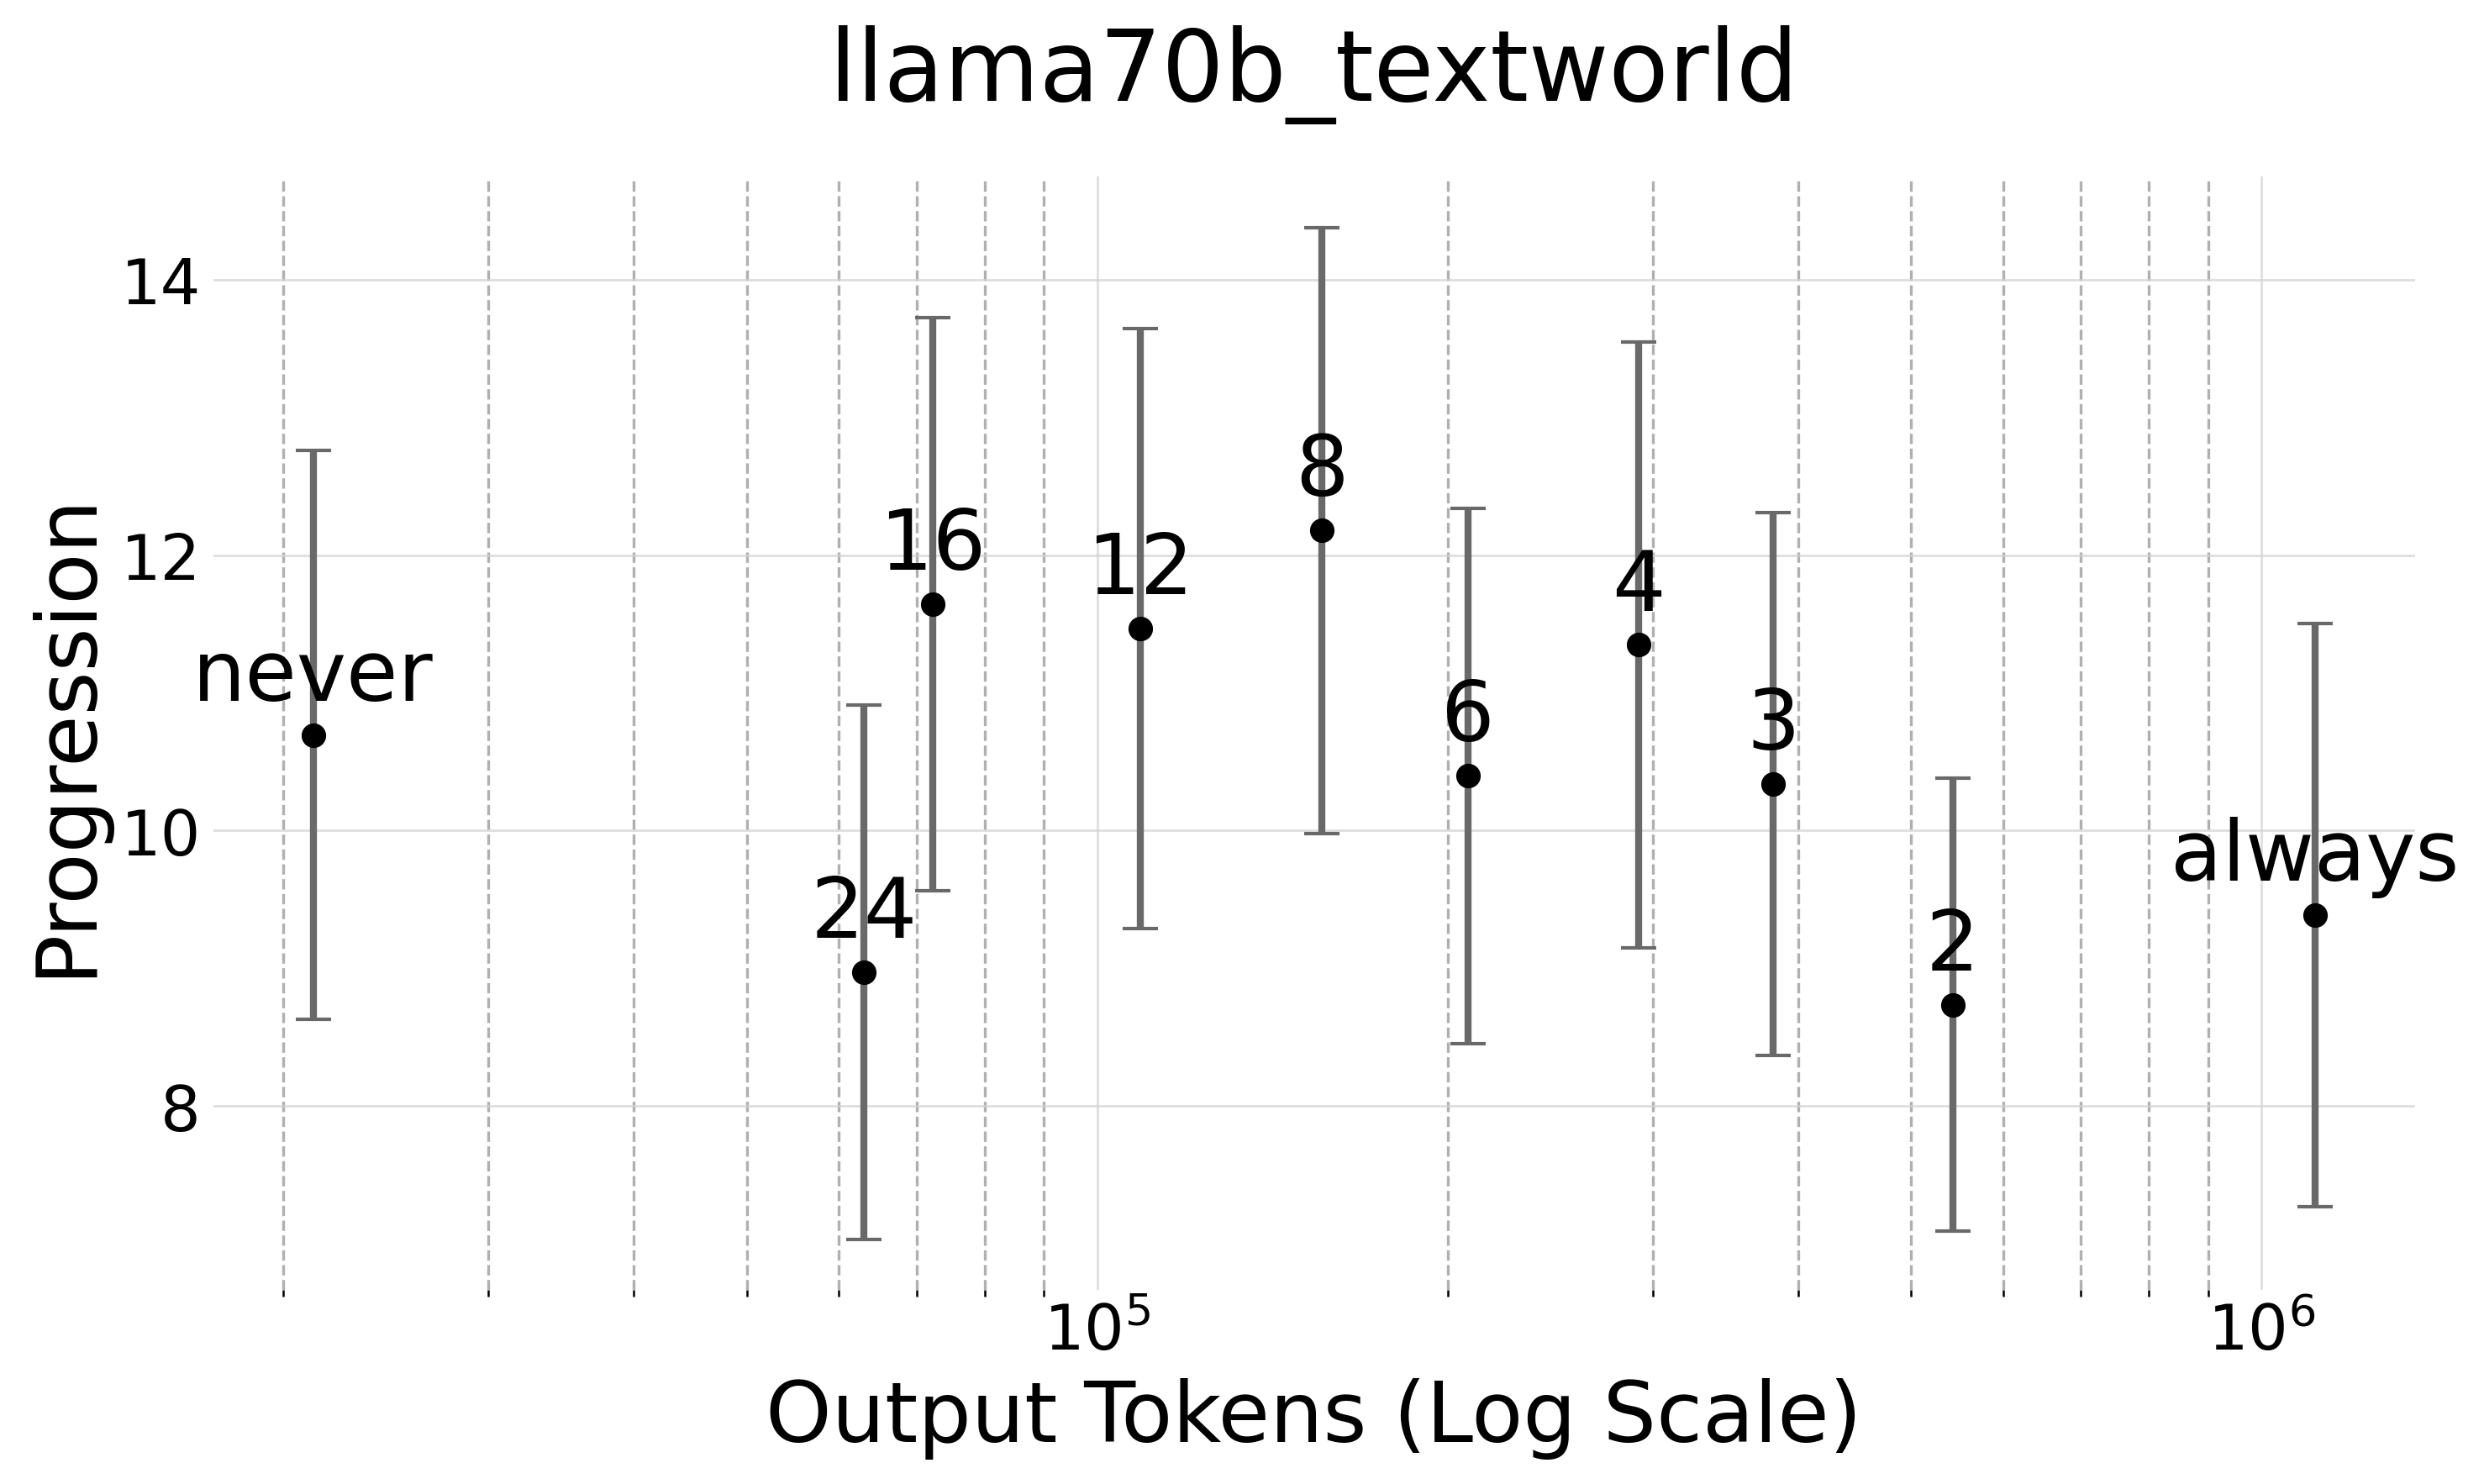

In [5]:
make_a_plot("/home/bartek_sakana_ai/BALROG/multirun/llama70b_textworld")

Scanning /home/bartek_sakana_ai/BALROG/multirun/llama70b_minihack...

### Aggregated Results Table
| Method | Model | Planning | Progression | Avg. Output Tokens |
| :--- | :--- | :--- | :--- | :--- |
| Zero-shot | Llama-3.3-70B-Instruct | Always (Every step) | 15.000 ± 3.571 | 1595157.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 2 steps | 5.000 ± 2.179 | 855714.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 3 steps | 5.000 ± 2.179 | 582050.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 4 steps | 5.000 ± 2.179 | 428522.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 6 steps | 4.000 ± 1.960 | 292941.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 8 steps | 7.000 ± 2.551 | 222783.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 12 steps | 4.000 ± 1.960 | 158390.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 16 steps | 1.000 ± 0.995 | 113511.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Every 24 steps | 4.000 ± 1.960 | 85879.0 |
| Zero-shot | Llama-3.3-70B-Instruct | Never | 1.00

/var/tmp/ipykernel_3540517/2608917604.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


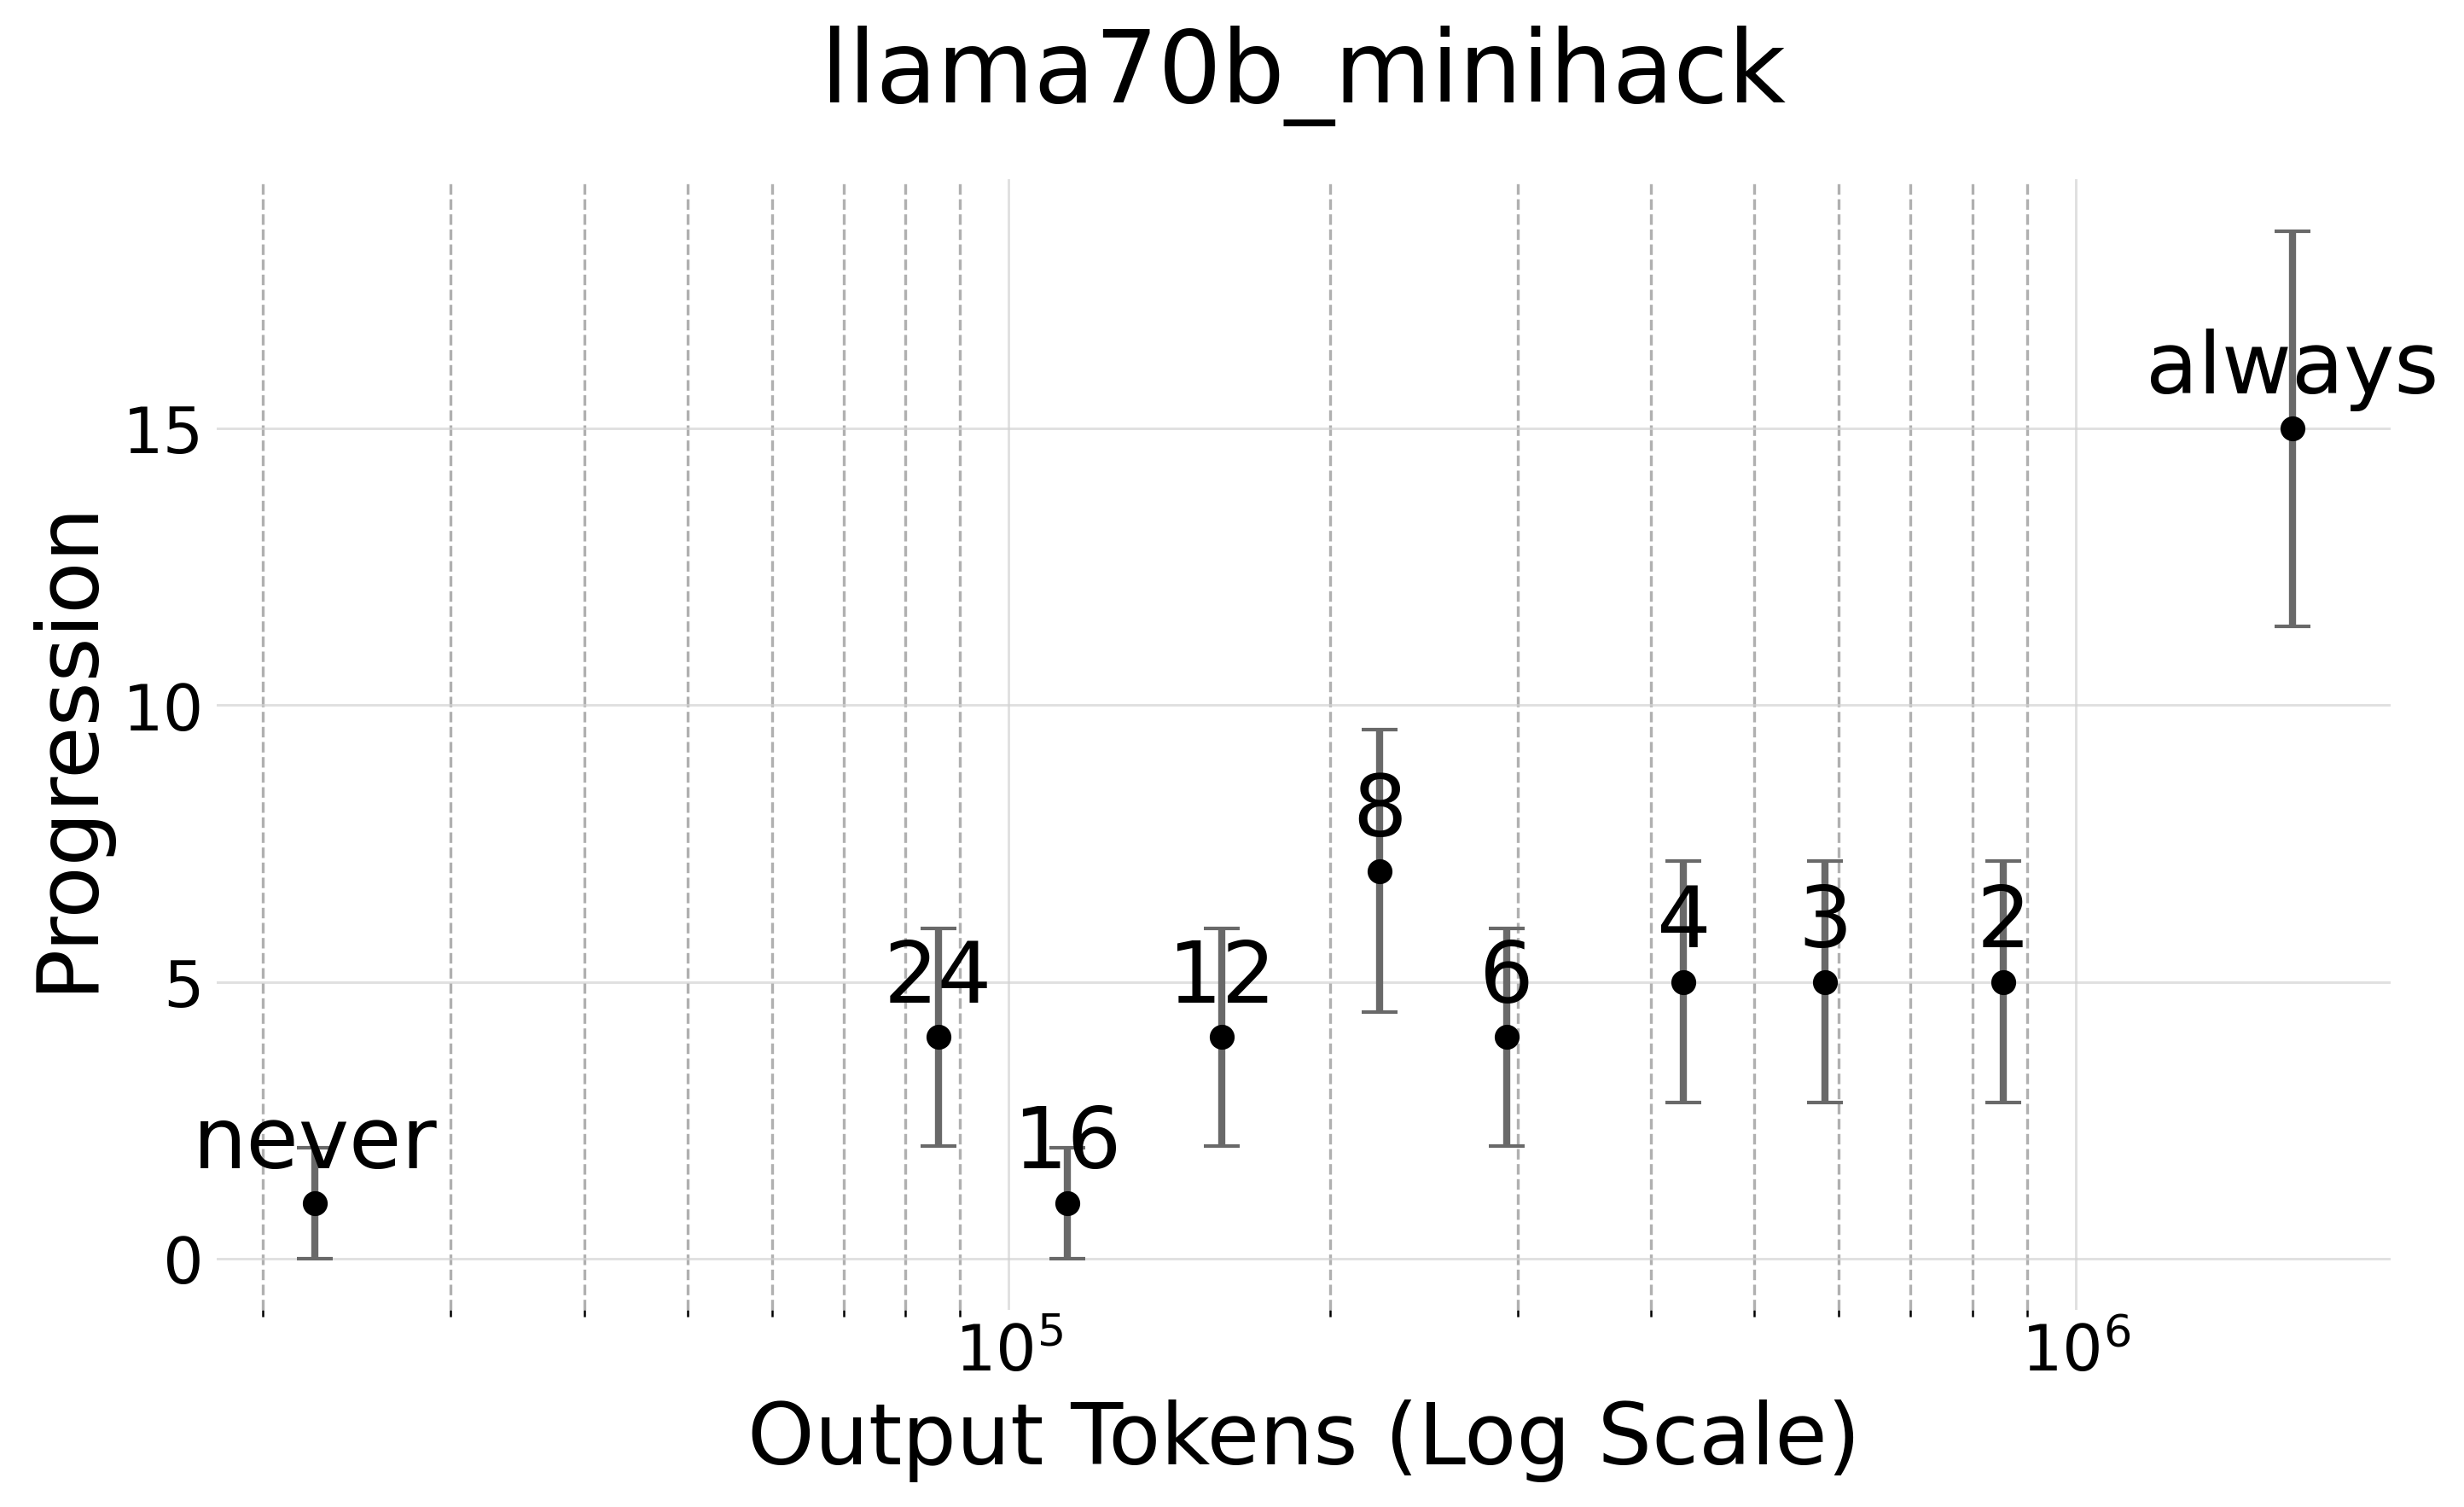

In [6]:
make_a_plot("/home/bartek_sakana_ai/BALROG/multirun/llama70b_minihack")

Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_pogs...

### Aggregated Results Table
| Method | Model | Planning | Progression | Avg. Output Tokens |
| :--- | :--- | :--- | :--- | :--- |
| Zero-shot | Llama-3.1-8B-Instruct | Always (Every step) | 15.758 ± 3.434 | 607323.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 2 steps | 26.697 ± 3.763 | 282734.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 3 steps | 30.551 ± 4.090 | 182958.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 4 steps | 25.557 ± 3.752 | 145948.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 6 steps | 30.212 ± 3.897 | 90865.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 8 steps | 29.290 ± 3.992 | 76349.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 12 steps | 24.850 ± 3.719 | 56367.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 16 steps | 22.860 ± 3.689 | 42180.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 24 steps | 26.400 ± 3.879 | 38307.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Never | 20.210 ± 3.502 |

/var/tmp/ipykernel_3540517/2608917604.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


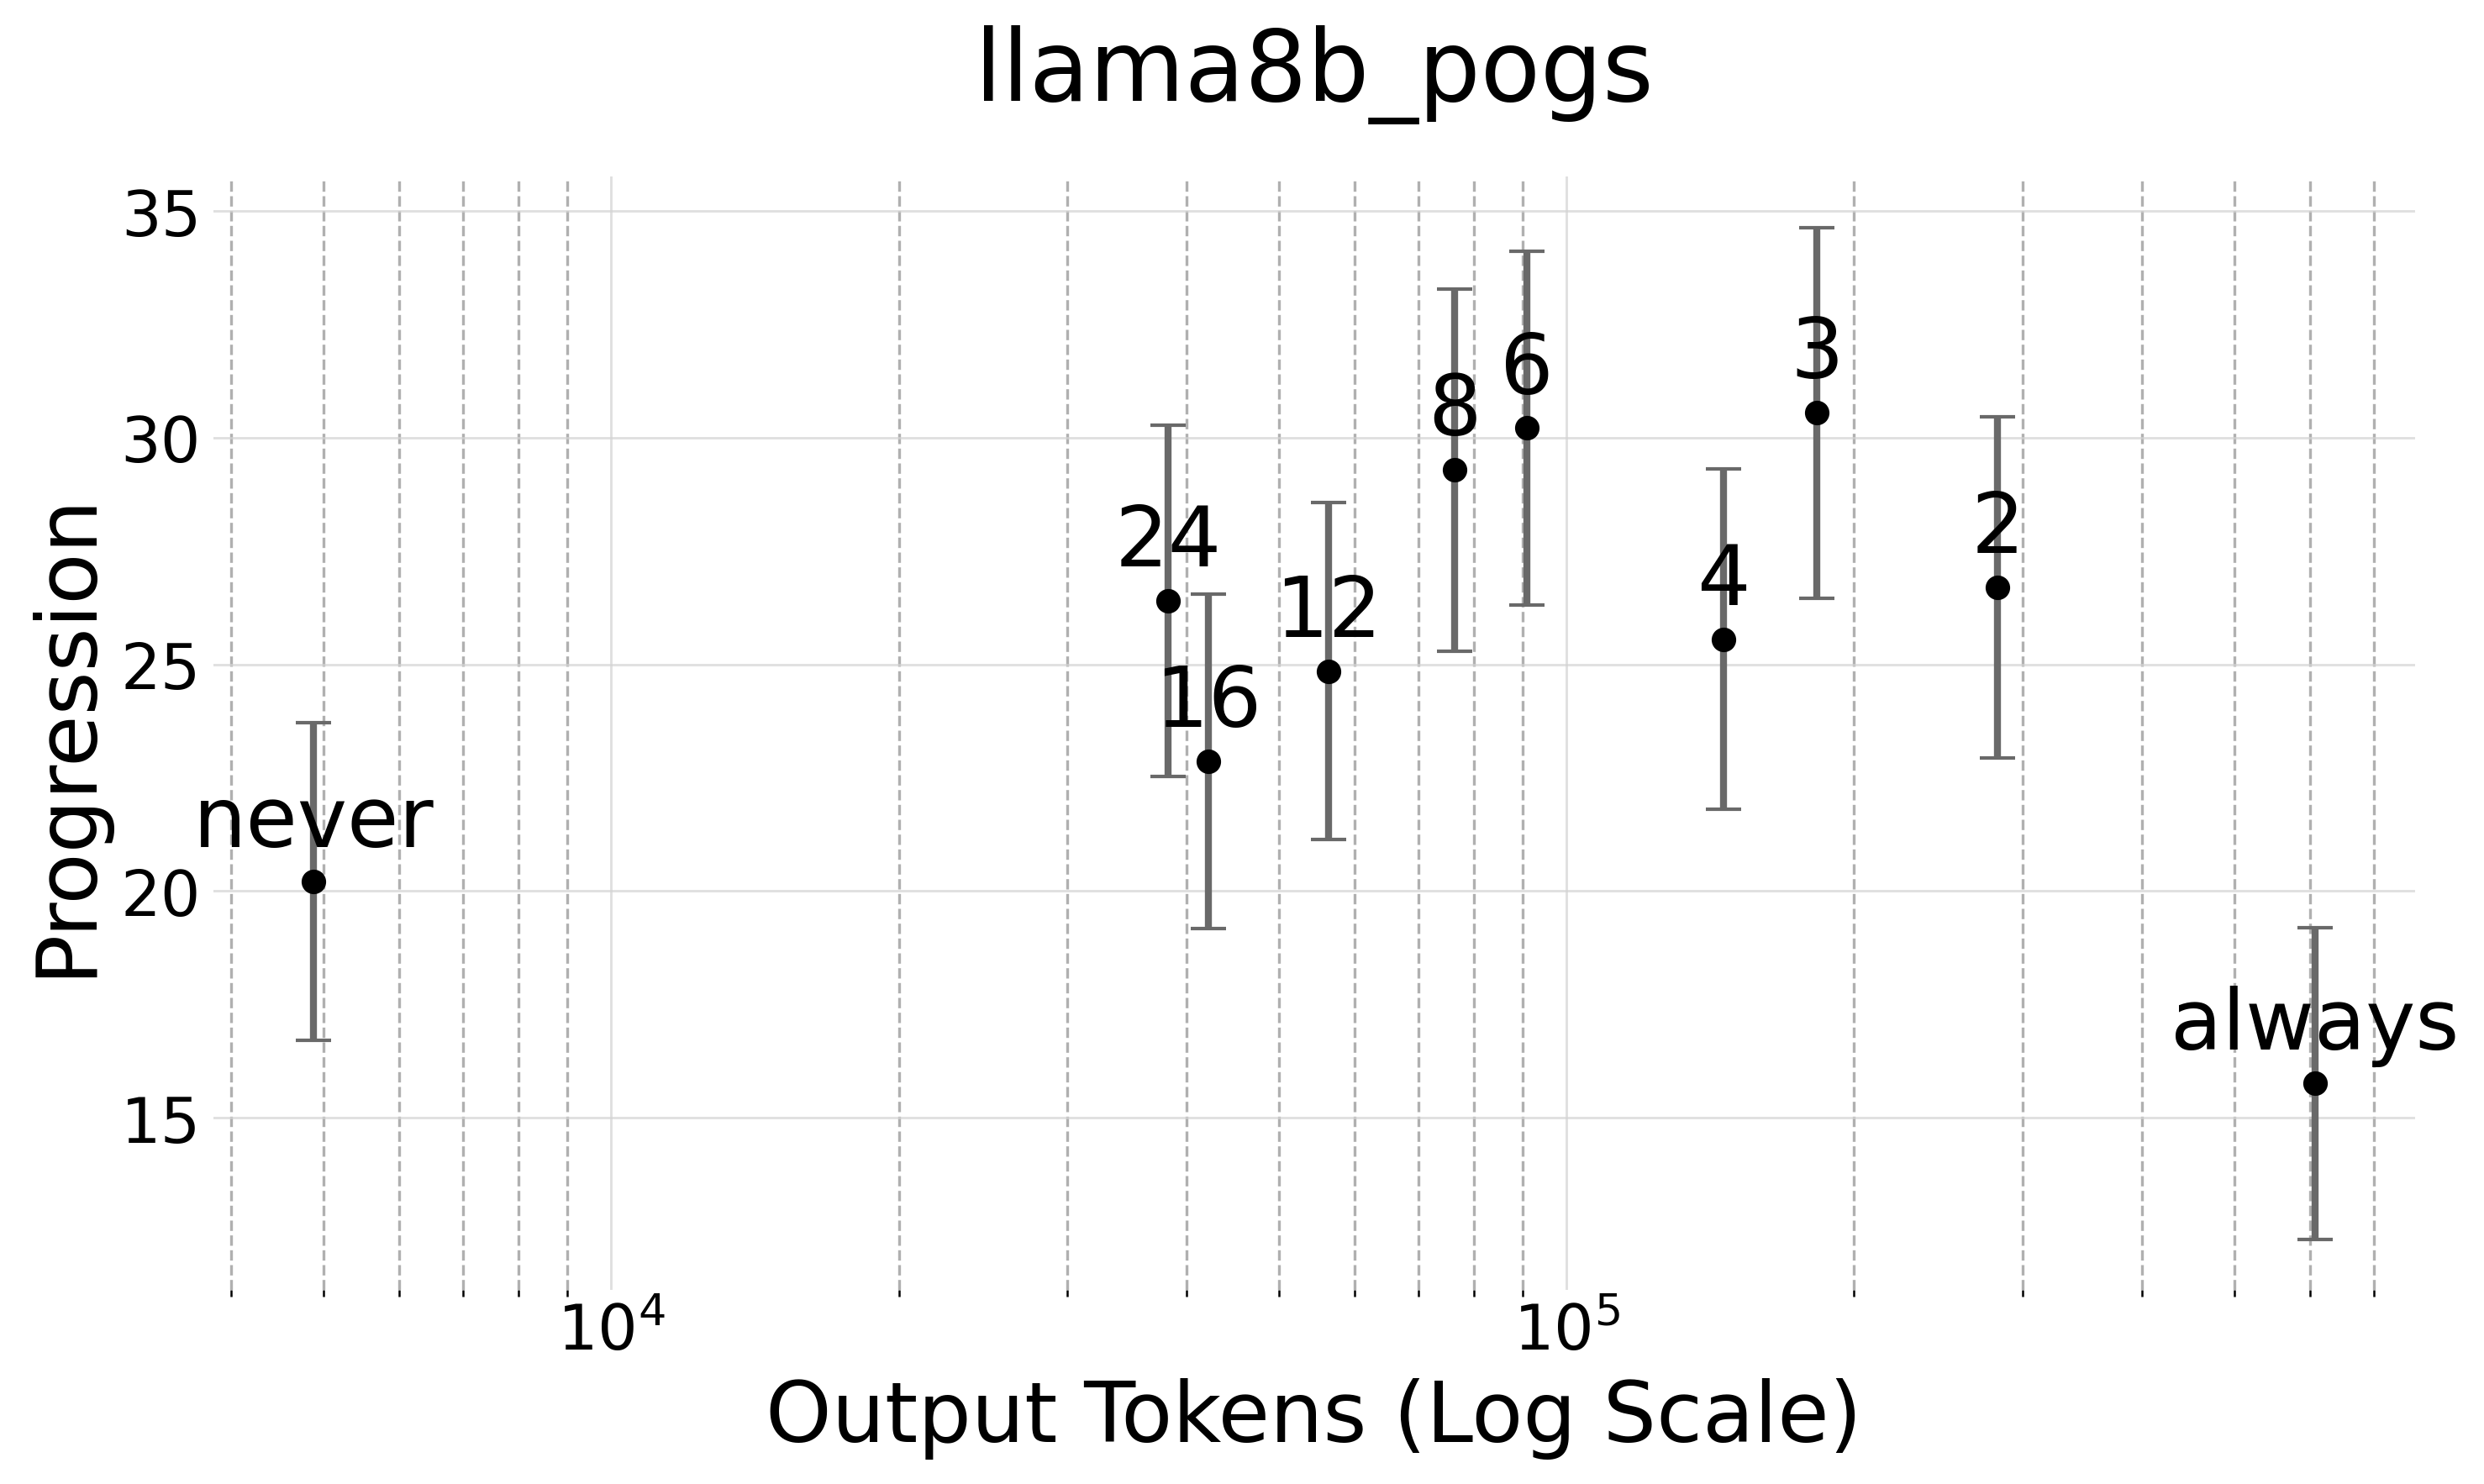

In [7]:
make_a_plot("/home/bartek_sakana_ai/BALROG/multirun/llama8b_pogs")

Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_textworld...

### Aggregated Results Table
| Method | Model | Planning | Progression | Avg. Output Tokens |
| :--- | :--- | :--- | :--- | :--- |
| Zero-shot | Llama-3.1-8B-Instruct | Always (Every step) | 0.416 ± 0.210 | 1700531.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 2 steps | 1.426 ± 0.386 | 723546.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 3 steps | 2.258 ± 0.574 | 477424.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 4 steps | 2.761 ± 0.675 | 348374.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 6 steps | 3.268 ± 0.789 | 243647.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 8 steps | 4.219 ± 1.277 | 172787.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 12 steps | 3.506 ± 0.943 | 127463.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 16 steps | 3.803 ± 0.956 | 87706.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 24 steps | 4.397 ± 1.084 | 72446.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Never | 3.803 ± 0.906 | 

/var/tmp/ipykernel_3540517/2608917604.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


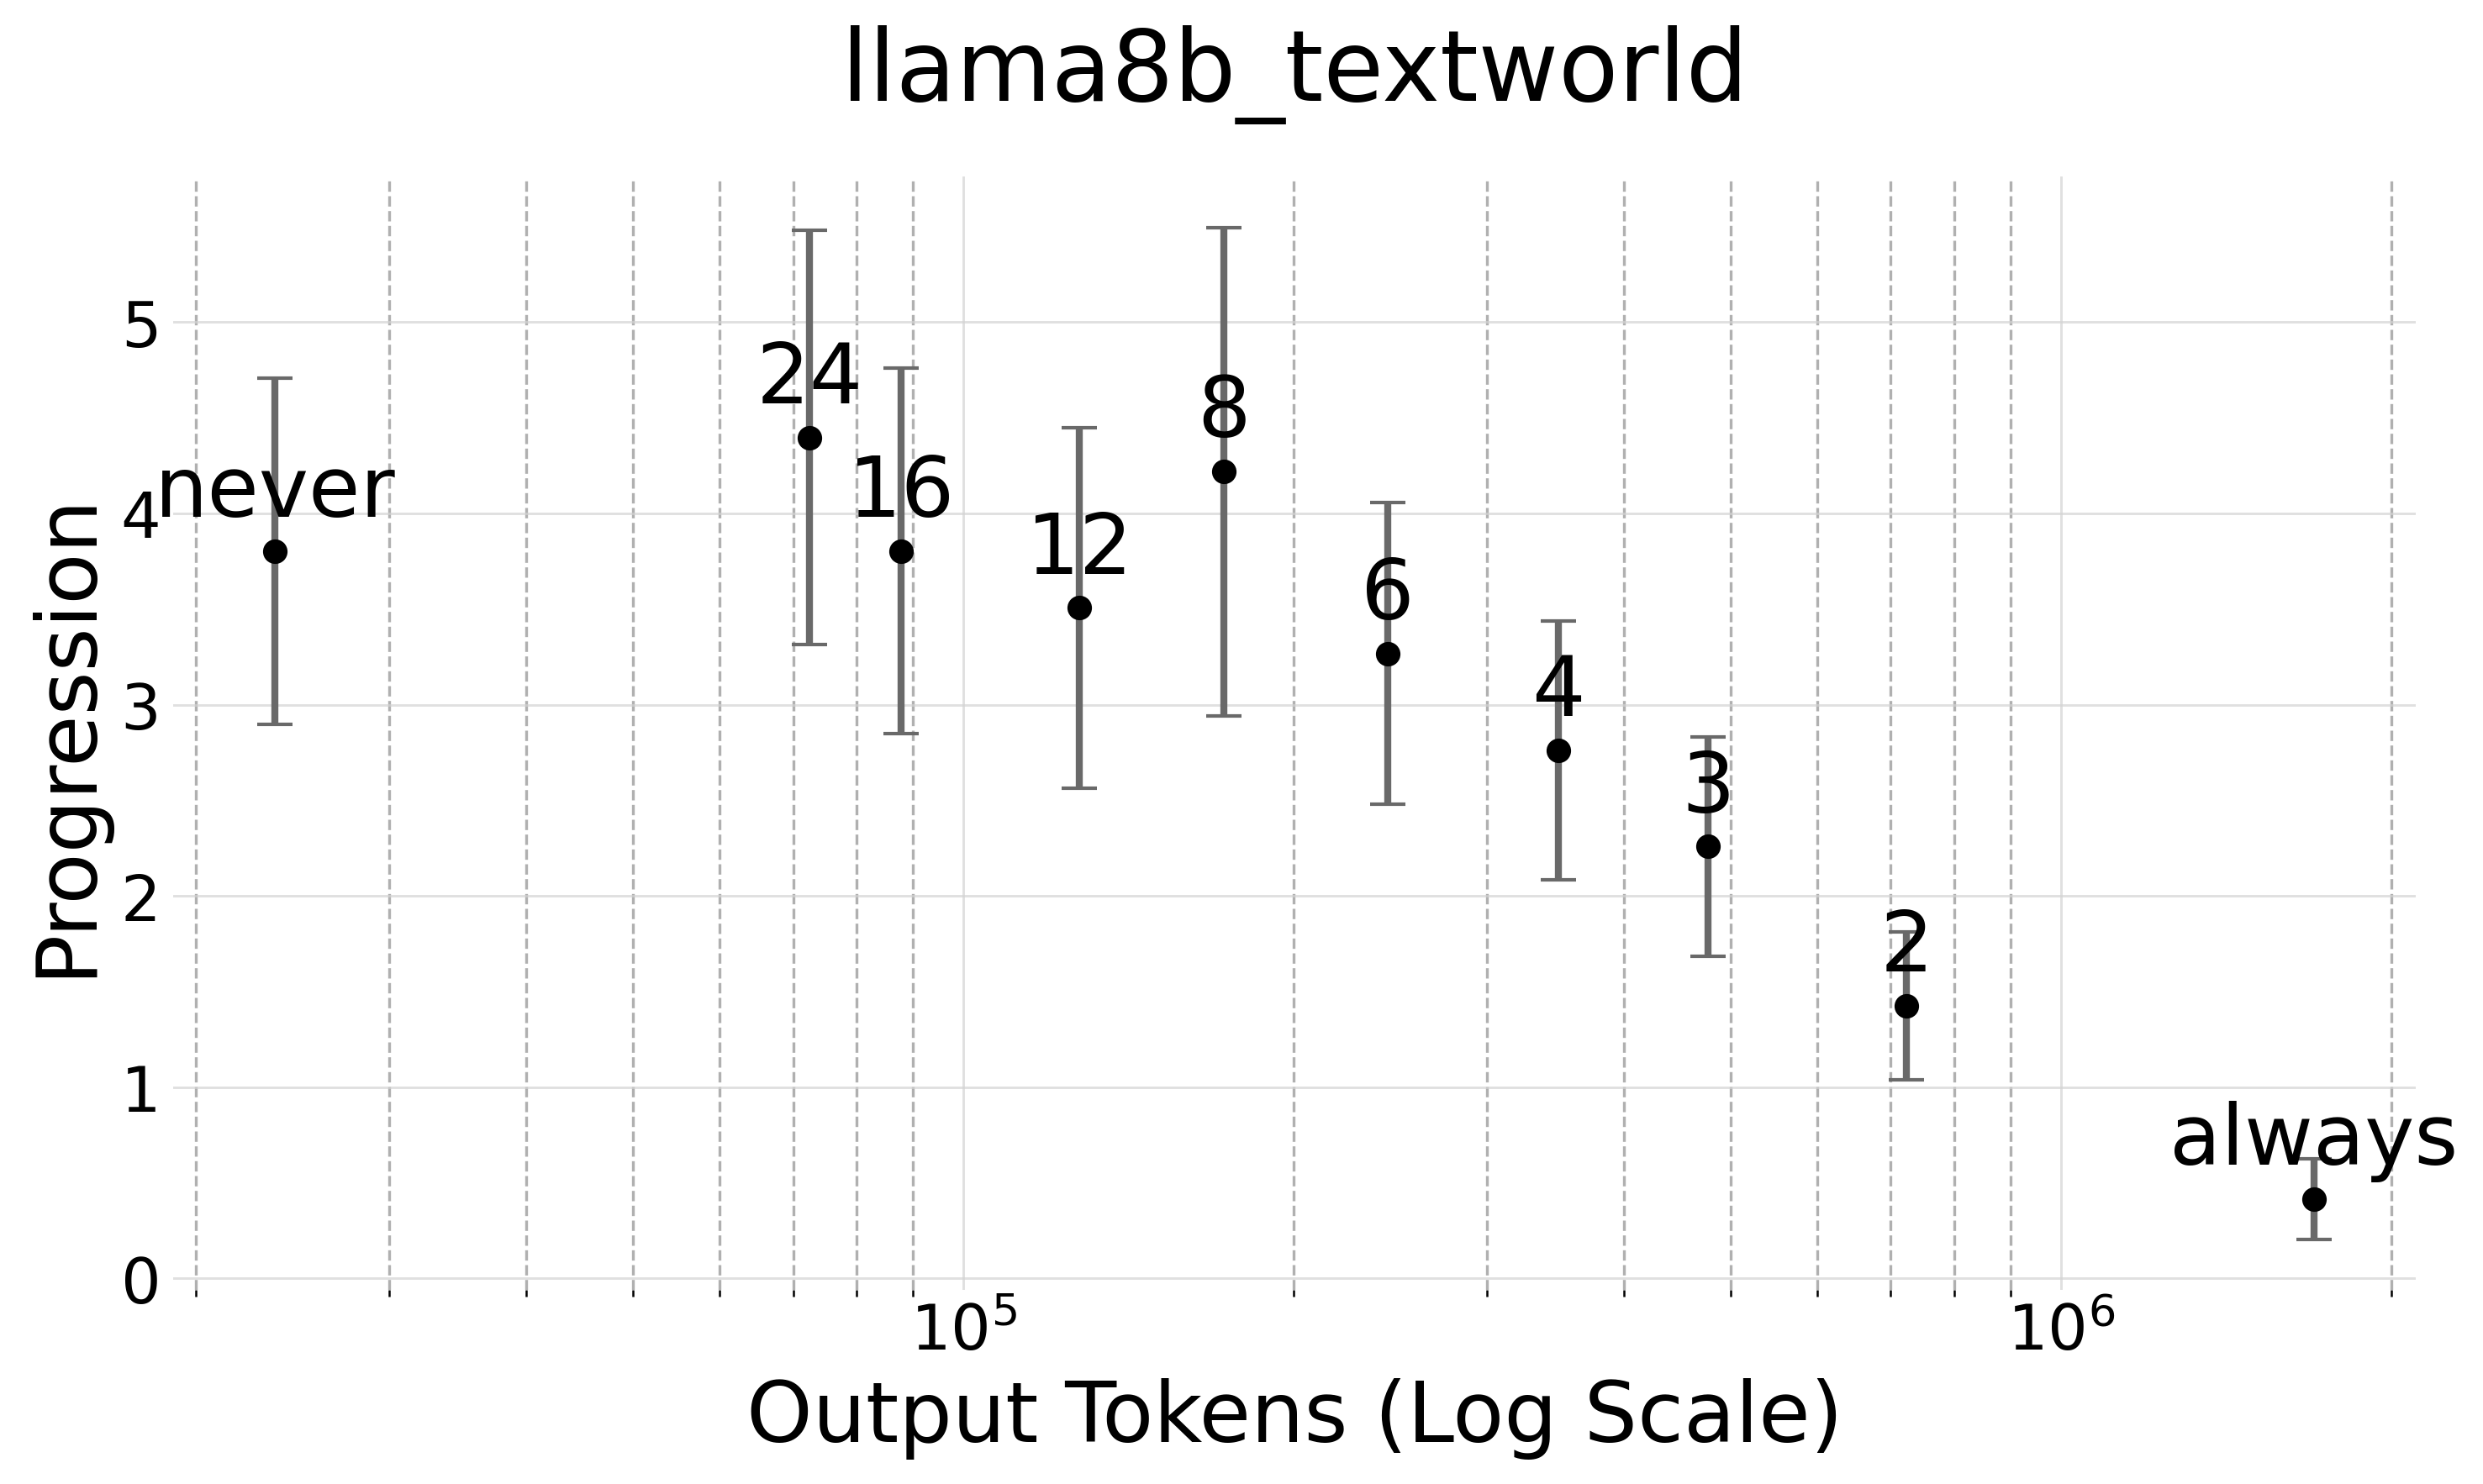

In [8]:
make_a_plot("/home/bartek_sakana_ai/BALROG/multirun/llama8b_textworld")

Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_minihack...

### Aggregated Results Table
| Method | Model | Planning | Progression | Avg. Output Tokens |
| :--- | :--- | :--- | :--- | :--- |
| Zero-shot | Llama-3.1-8B-Instruct | Always (Every step) | 1.163 ± 1.156 | 1503175.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 2 steps | 2.000 ± 1.400 | 827711.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 3 steps | 1.000 ± 0.995 | 532953.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 4 steps | 3.000 ± 1.706 | 371273.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 6 steps | 1.000 ± 0.995 | 253501.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 8 steps | 1.000 ± 0.995 | 199704.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 12 steps | 1.010 ± 1.005 | 142373.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 16 steps | 0.000 ± 0.000 | 101020.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 24 steps | 0.000 ± 0.000 | 77984.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Never | 1.000 ± 0.995 | 

/var/tmp/ipykernel_3540517/2608917604.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


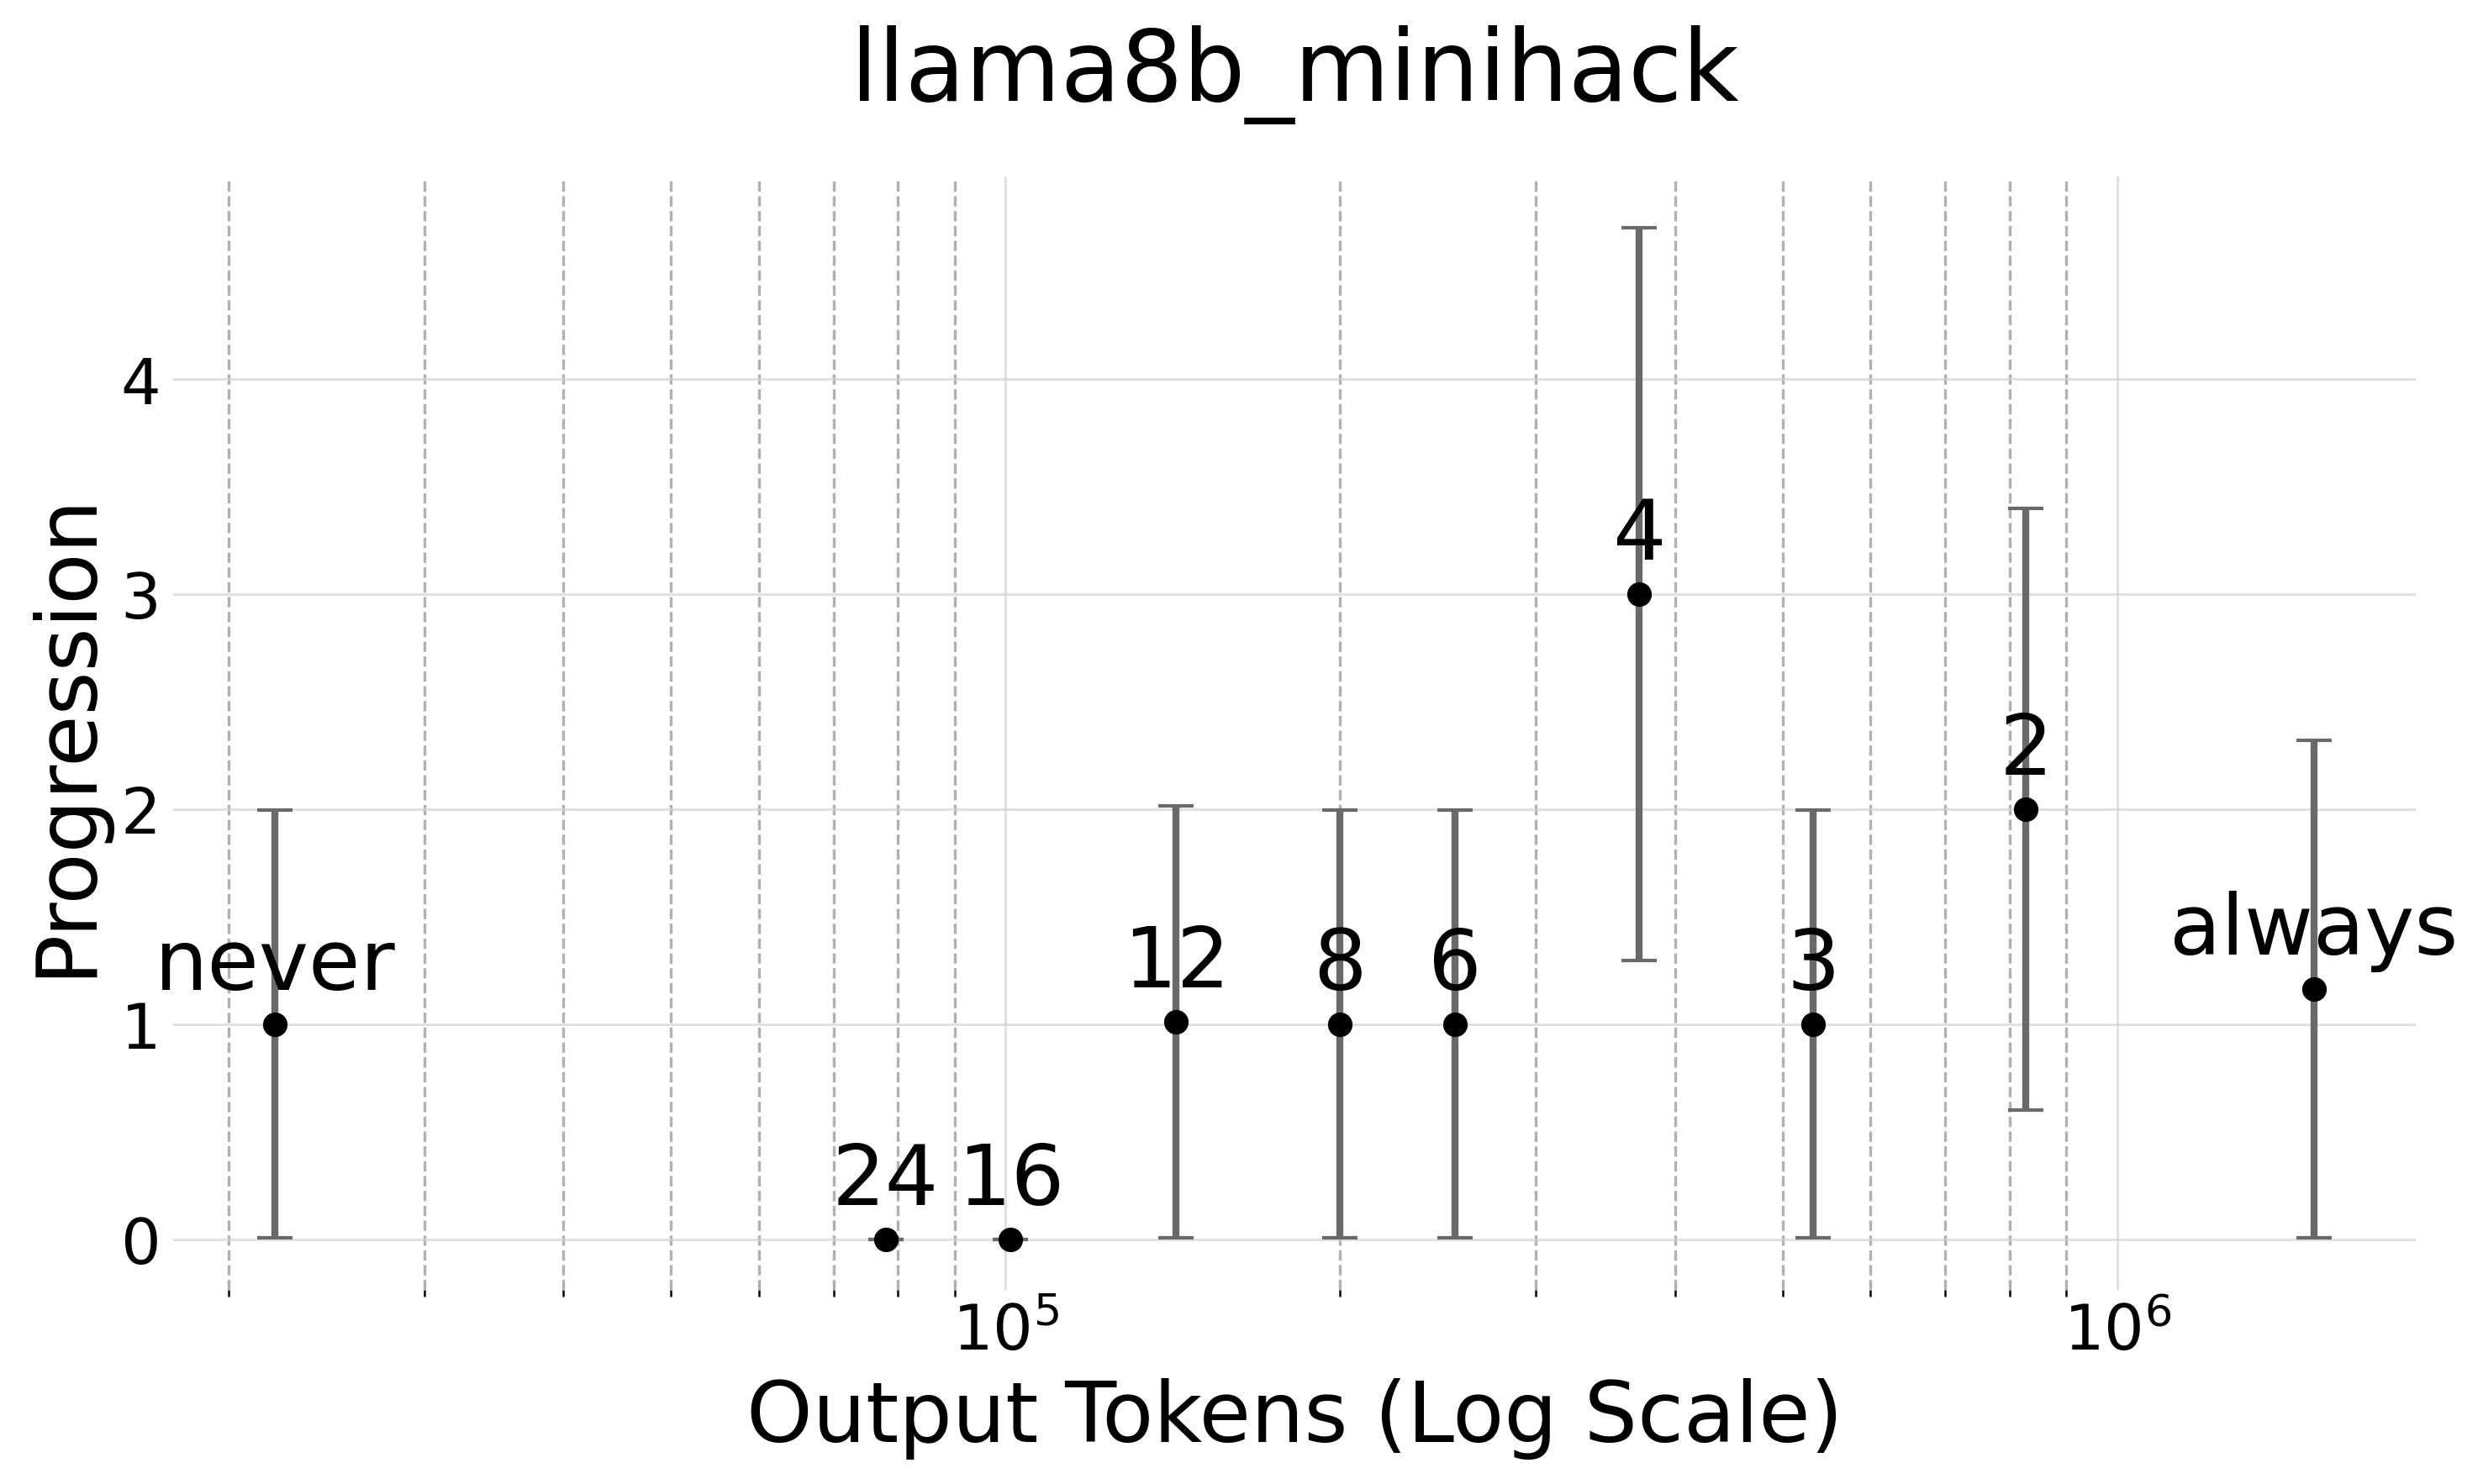

In [9]:
make_a_plot("/home/bartek_sakana_ai/BALROG/multirun/llama8b_minihack")

Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_crafter...

### Aggregated Results Table
| Method | Model | Planning | Progression | Avg. Output Tokens |
| :--- | :--- | :--- | :--- | :--- |
| Zero-shot | Llama-3.1-8B-Instruct | Always (Every step) | 2.433 ± 0.314 | 4426453.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 2 steps | 12.455 ± 0.732 | 2596940.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 3 steps | 15.335 ± 0.820 | 1562155.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 4 steps | 17.136 ± 0.869 | 1287836.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 6 steps | 18.364 ± 0.869 | 838788.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 8 steps | 18.825 ± 0.861 | 568136.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 12 steps | 19.192 ± 0.805 | 398708.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 16 steps | 21.500 ± 1.016 | 273198.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Every 24 steps | 18.818 ± 0.936 | 199952.0 |
| Zero-shot | Llama-3.1-8B-Instruct | Never | 19.68

/var/tmp/ipykernel_3540517/2608917604.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


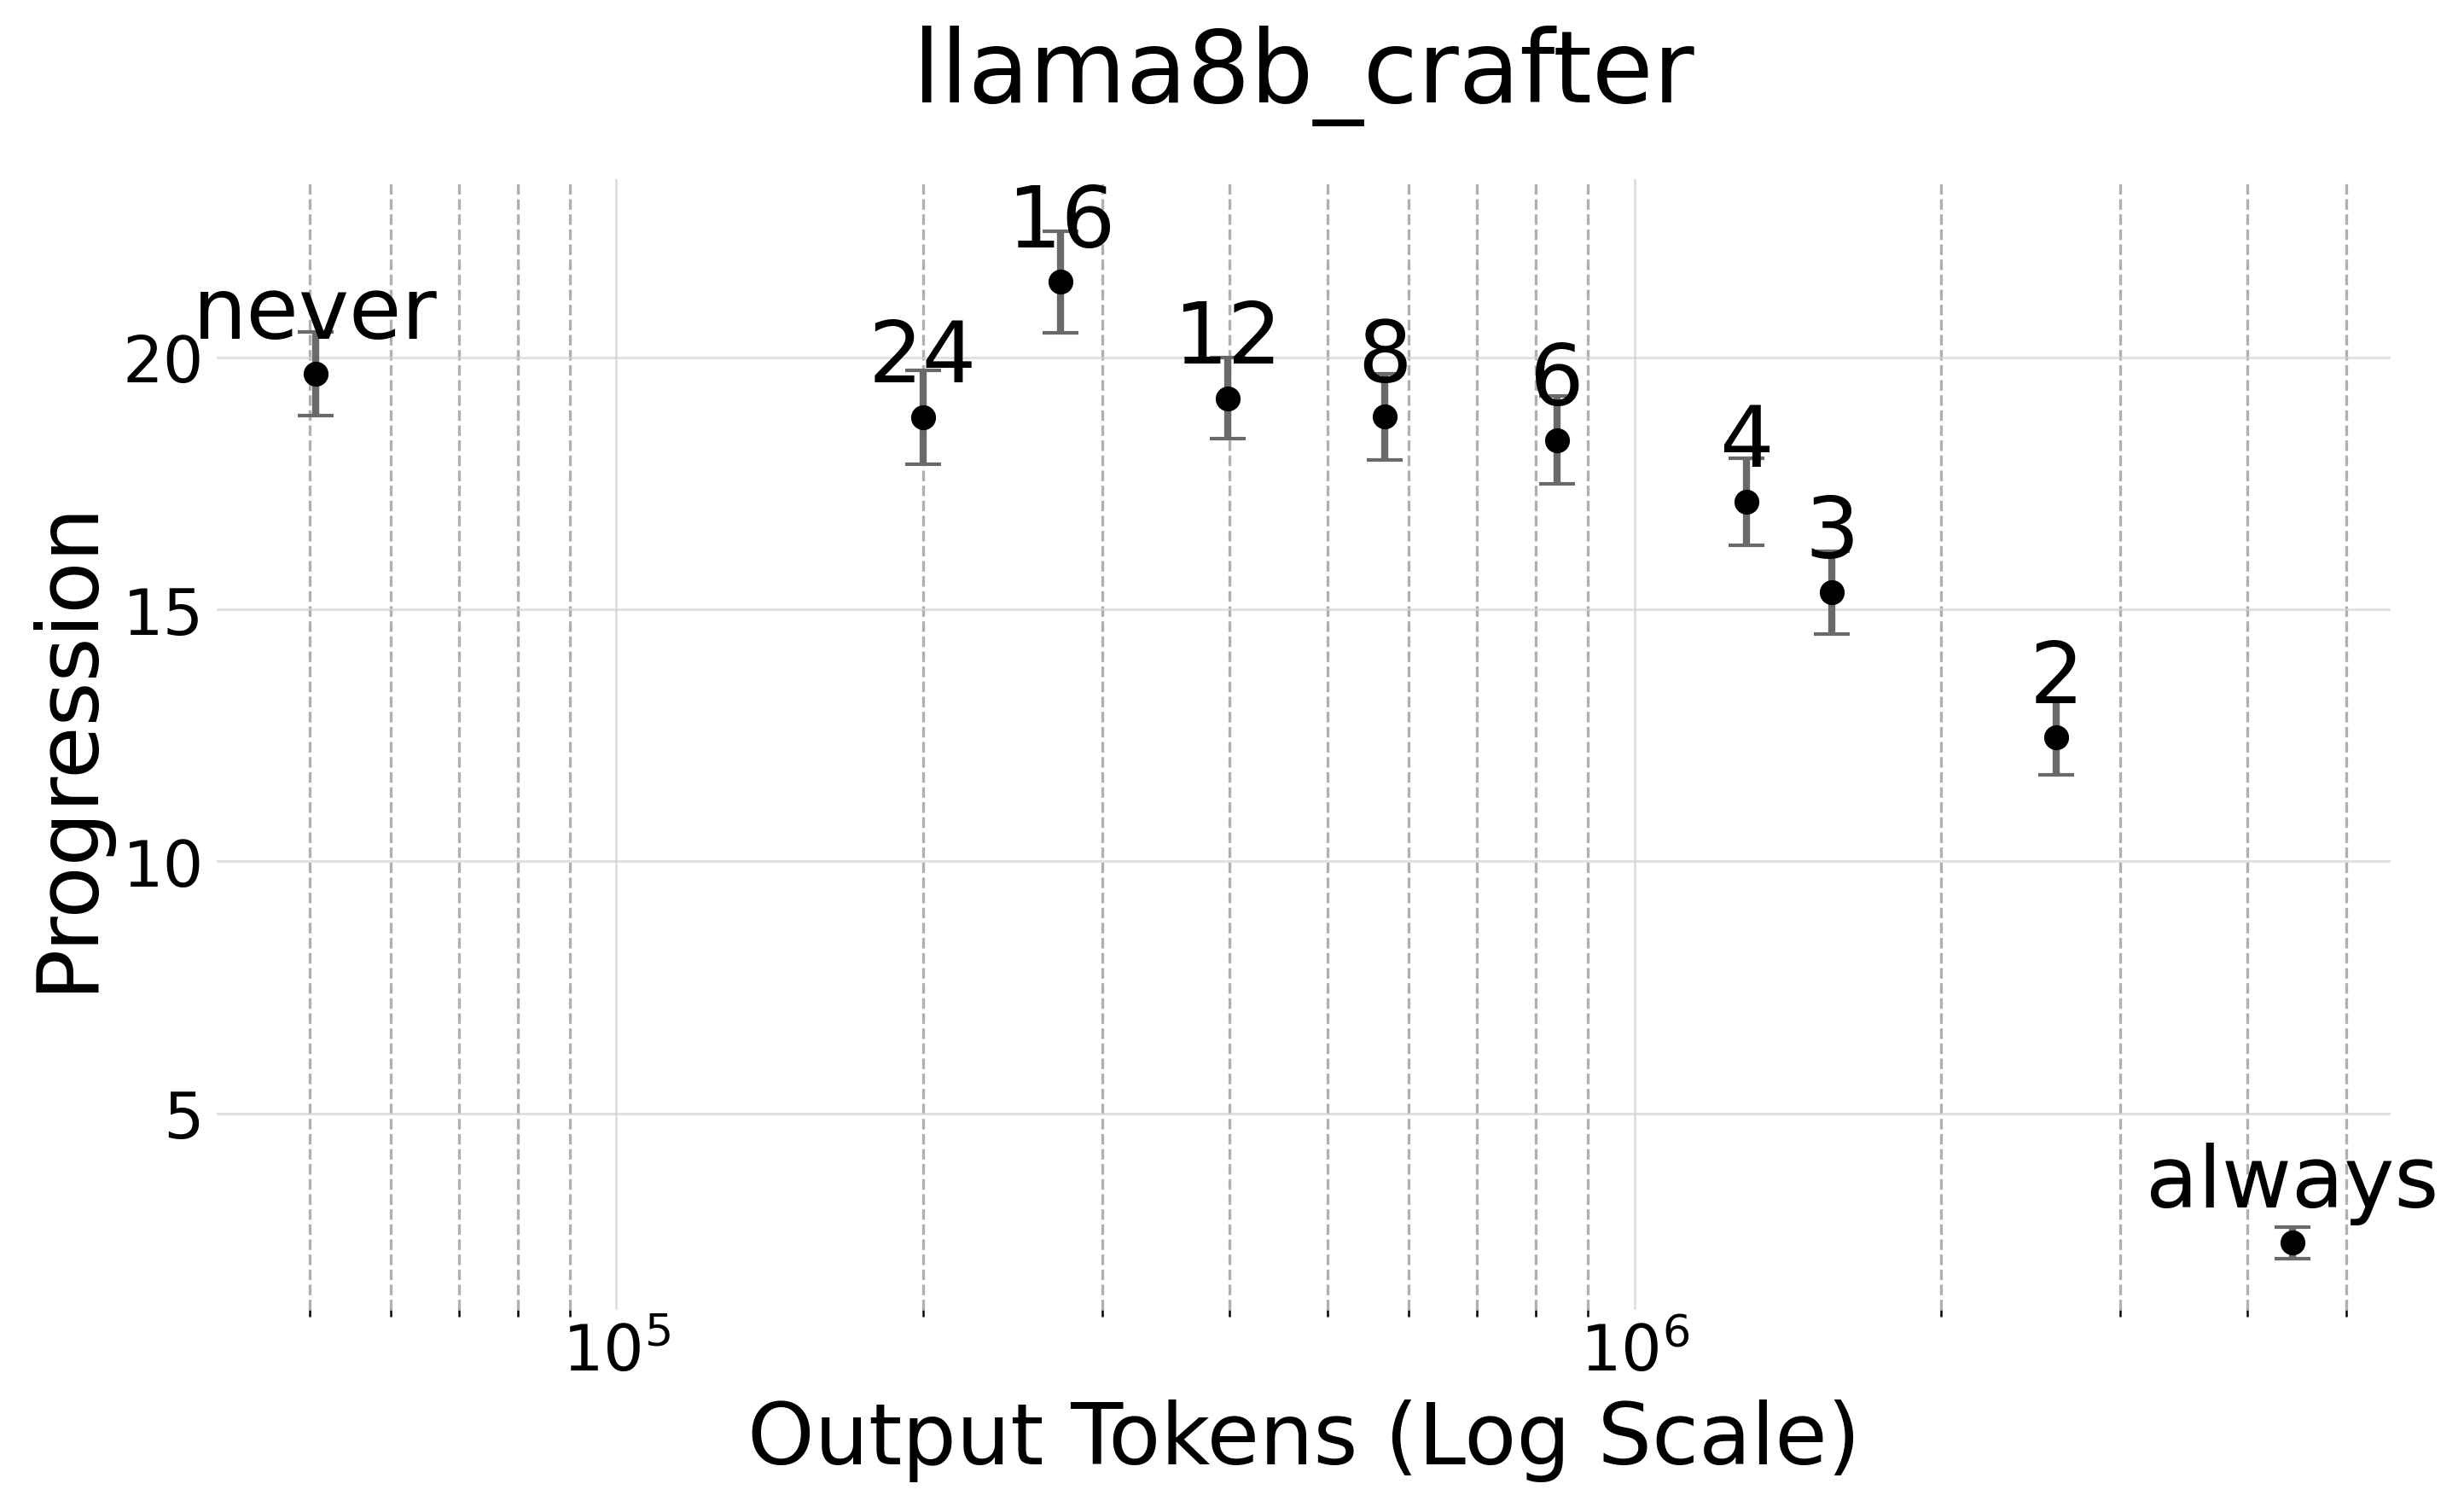

In [10]:
make_a_plot("/home/bartek_sakana_ai/BALROG/multirun/llama8b_crafter")

Scanning /home/bartek_sakana_ai/BALROG/multirun/llama70b_crafter...
Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_crafter...
Scanning /home/bartek_sakana_ai/BALROG/multirun/gpt-oss-20b_crafter...
Scanning /home/bartek_sakana_ai/BALROG/multirun/gpt-oss-120b_crafter...
Scanning /home/bartek_sakana_ai/BALROG/multirun/llama70b_minihack...


Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_minihack...
Scanning /home/bartek_sakana_ai/BALROG/multirun/llama70b_textworld...
Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_textworld...
Scanning /home/bartek_sakana_ai/BALROG/multirun/llama70b_pogs...
Scanning /home/bartek_sakana_ai/BALROG/multirun/llama8b_pogs...


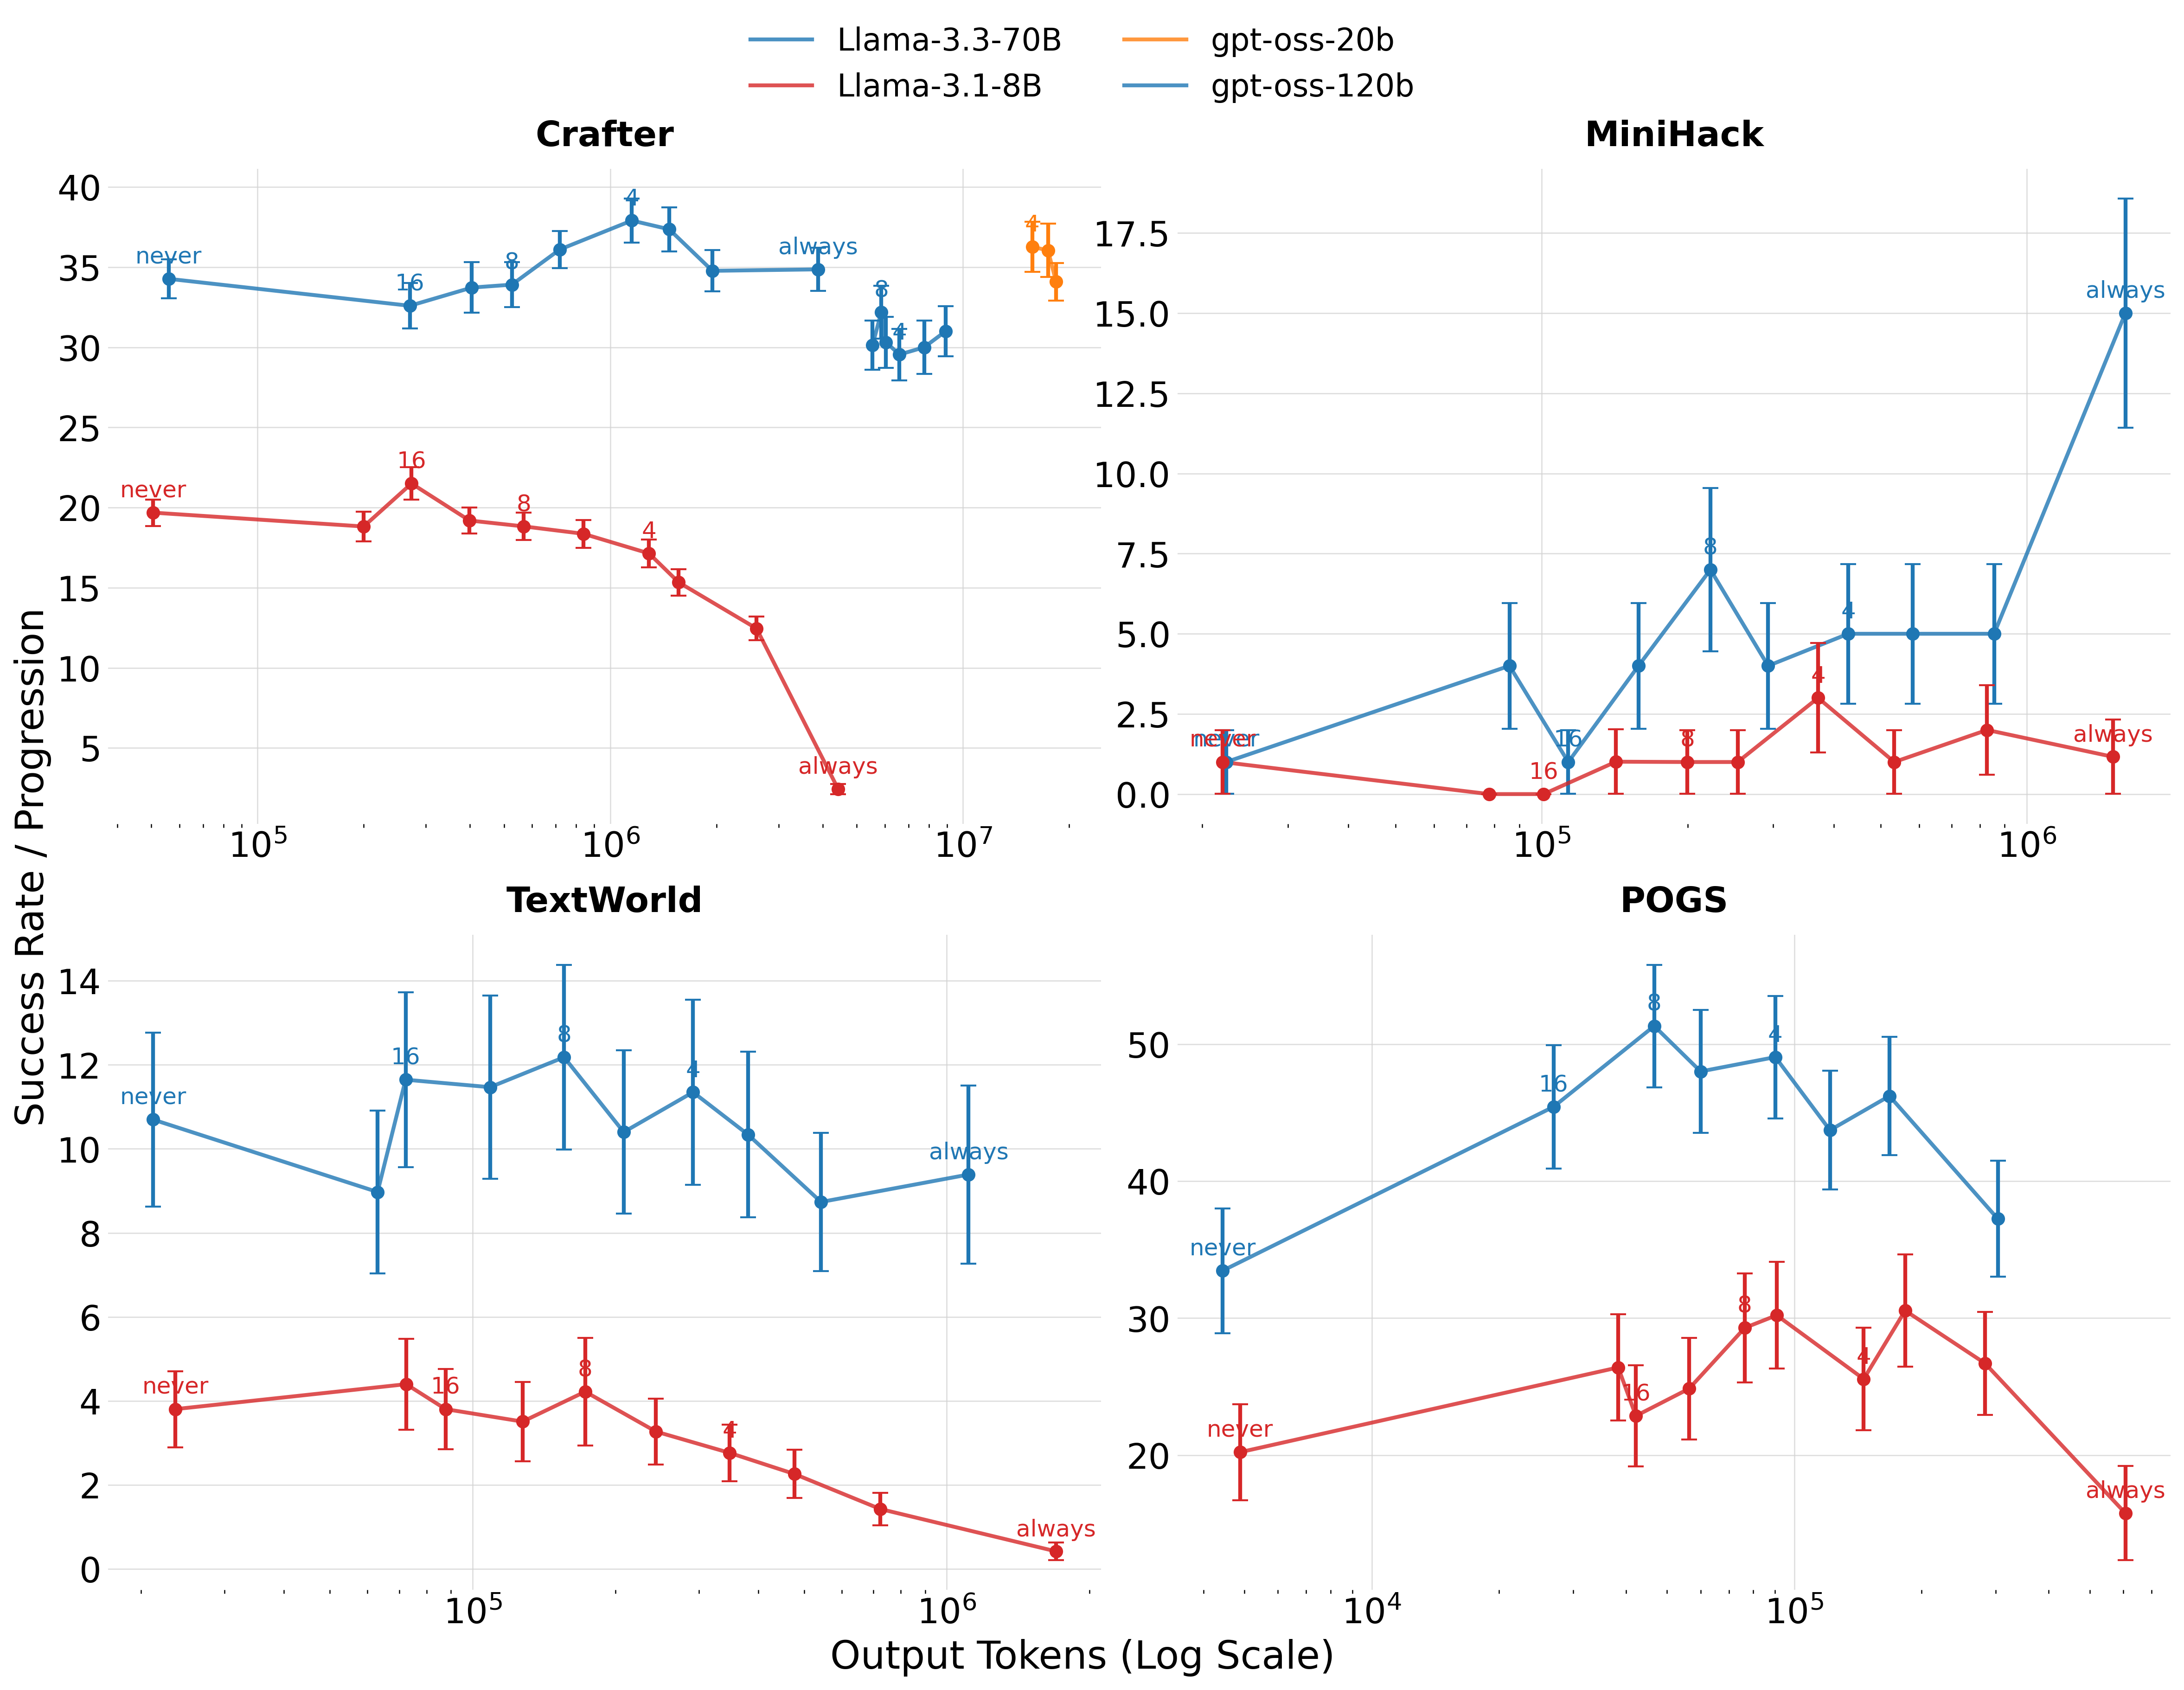

In [11]:
import json
import os
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
# Common choices: 'Arial', 'Helvetica', 'DejaVu Sans' (default)
# If 'Arial' or 'Helvetica' are not available, Matplotlib will fall back.
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.titlesize'] = 28 # Title font size
plt.rcParams['axes.labelsize'] = 24 # Axis label font size
plt.rcParams['xtick.labelsize'] = 18  # X-tick label font size
plt.rcParams['ytick.labelsize'] = 18 # Y-tick label font size
plt.rcParams['legend.fontsize'] = 15 # Legend font size
plt.rcParams['lines.linewidth'] = 2.0 # Default line width for plots


# --- Reuse your existing aggregation function ---
def aggregate_balrog_results(root_directory):
    """
    Walks through a Hydra multirun directory structure to aggregate BALROG results.
    """
    # Stores raw values
    raw_data = defaultdict(lambda: {"progression_percentage": [], "standard_error": [], "output_tokens": [], "average_steps": []})
    
    # Store metadata mapping (Planning Key -> Model Name)
    key_metadata = {}

    print(f"Scanning {root_directory}...")
    
    for root, dirs, files in os.walk(root_directory):
        if "summary.json" in files:
            try:
                with open(os.path.join(root, "summary.json"), 'r') as f:
                    summary_conf = json.load(f)
                
                agent_conf = summary_conf.get("agent", {})
                client_conf = summary_conf.get("client", {})
                agent_type = agent_conf.get("type", "")
                
                model_name = client_conf.get("model_id", "Llama-3.3-70B")
                if "/" in model_name: 
                    model_name = model_name.split("/")[-1]

                if agent_type == "never_plan":
                    key_name = "never_plan"
                elif agent_type == "always_plan":
                    key_name = "always_plan"
                elif "plan_every" in agent_type:
                    k = agent_conf.get("plan_k")
                    if k is not None:
                        key_name = f"plan_every_{k}"
                    else:
                        continue
                else:
                    continue
                
                key_metadata[key_name] = model_name

            except Exception as e:
                # print(f"Error reading summary at {root}: {e}")
                continue

            game_metrics = None
            for d in dirs:
                game_summary_path = os.path.join(root, d, f"{d}_summary.json")
                if os.path.exists(game_summary_path):
                    try:
                        with open(game_summary_path, 'r') as f:
                            game_metrics = json.load(f)
                        break 
                    except Exception as e:
                        continue
            
            if game_metrics:
                for metric in ["progression_percentage", "standard_error", "output_tokens", "average_steps"]:
                    if metric in game_metrics:
                        val = game_metrics[metric]
                        if isinstance(val, list):
                            raw_data[key_name][metric].extend(val)
                        else:
                            raw_data[key_name][metric].append(val)

    final_data_dict = {}
    for key, metrics in raw_data.items():
        results = {}
        for metric_name, values in metrics.items():
            if not values:
                results[metric_name] = (0.0, 0.0)
                continue
            arr = np.array(values)
            mean_val = float(np.mean(arr))
            stderr_val = float(np.std(arr) / np.sqrt(len(arr)))
            results[metric_name] = (mean_val, stderr_val)
        final_data_dict[key] = results
        
    return final_data_dict

# --- New Plotting Logic ---

def style_subplot(ax):
    ax.grid(True, color='lightgray', linestyle='-', linewidth=0.7, alpha=0.7)
    ax.tick_params(direction='out', length=0, width=0, colors='black')  # Turn off ticks
    for spine in ax.spines.values():
        spine.set_visible(False)  # Hide all spines (no edgecolor)
        

def plot_single_environment(ax, env_name, models_dict, label_map):
    """
    Plots lines for multiple models within a single environment subplot.
    models_dict: { "Llama-3": "/path/to/dir", "Gemini": "/path/to/dir" }
    """
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e'] # Blue, Red, Green, Orange
    
    for i, (model_label, root_dir) in enumerate(models_dict.items()):
        if not os.path.exists(root_dir):
            print(f"Warning: Path not found for {env_name} - {model_label}: {root_dir}")
            continue
            
        data_dict = aggregate_balrog_results(root_dir)
        
        # Extract and Sort Data
        points = []
        for key, data in data_dict.items():
            if data["progression_percentage"] and data["output_tokens"]:
                short_label = label_map.get(key, key)
                
                mean_tokens, _ = data["output_tokens"]
                mean_prog, _ = data["progression_percentage"]
                std_err_prog, _ = data["standard_error"]
                
                points.append({
                    "x": mean_tokens,
                    "y": mean_prog,
                    "y_err": std_err_prog,
                    "label": short_label
                })
        
        # Sort by X (Output Tokens) to ensure the line is connected correctly
        points.sort(key=lambda p: p["x"])
        
        if not points:
            continue
            
        X = [p["x"] for p in points]
        Y = [p["y"] for p in points]
        Y_ERR = [p["y_err"] for p in points]
        LABELS = [p["label"] for p in points]
        
        color = colors[i % len(colors)]
        
        # Plot Line
        ax.plot(X, Y, color=color, linewidth=2, alpha=0.8, label=model_label)
        
        # Plot Points & Error Bars
        ax.errorbar(X, Y, yerr=Y_ERR, fmt='o', capsize=4, color=color, markersize=6)
        
        # Annotate specific points (Optional: Avoid clutter if many lines)
        for j, txt in enumerate(LABELS):
            # Only label 'never', 'always', and maybe one intermediate to reduce clutter
            if txt in ['never', 'always', '4', '8', '16']: 
                ax.annotate(txt, (X[j], Y[j]), textcoords="offset points", 
                           xytext=(0, 8), ha='center', fontsize=12, color=color)

    ax.set_title(env_name, fontsize=18, fontweight='bold', pad=12)
    ax.set_xscale('log', base=10)
    style_subplot(ax)


def make_goldilocks_grid(environments):
    """
    Main function to generate the 2x2 grid.
    environments: Nested dict structure:
      {
        "Crafter": { "Llama": "path...", "Gemini": "path..." },
        "POGS": { ... },
        ...
      }
    """
    # Global Style Settings
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    
    # Setup Figure 2x2
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
    axes = axes.flatten()
    fig.patch.set_alpha(0.0)
    
    # Label Mapping
    label_map = {
        "never_plan": "never",
        "always_plan": "always",
        "plan_every_2": "2",
        "plan_every_3": "3",     
        "plan_every_4": "4",
        "plan_every_6": "6",
        "plan_every_8": "8",
        "plan_every_10": "10",
        "plan_every_12": "12",
        "plan_every_16": "16",
        "plan_every_24": "24",
    }
    
    # Loop through environments and plot
    for i, (env_name, models) in enumerate(environments.items()):
        if i < len(axes):
            plot_single_environment(axes[i], env_name, models, label_map)
    
    # Common Labels
    fig.text(0.5, 0.02, 'Output Tokens (Log Scale)', ha='center', fontsize=20)
    fig.text(0.02, 0.5, 'Success Rate / Progression', va='center', rotation='vertical', fontsize=20)
    
    # Legend (Collect handles from the first plot that has data)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
                   ncol=2, fontsize=16, frameon=False)
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.96]) # Make room for common labels
    plt.show()

    

# ==========================================
#  CONFIGURE YOUR PATHS HERE
# ==========================================

# Replace these paths with your actual directories
my_environments = {
    "Crafter": {
        "Llama-3.3-70B": "/home/bartek_sakana_ai/BALROG/multirun/llama70b_crafter",
        "Llama-3.1-8B": "/home/bartek_sakana_ai/BALROG/multirun/llama8b_crafter",
        "Gemini-2.5-Flash": "/home/bartek_sakana_ai/BALROG/multirun/gemini-flash_crafter",
        "gpt-oss-20b": "/home/bartek_sakana_ai/BALROG/multirun/gpt-oss-20b_crafter",
        "gpt-oss-120b": "/home/bartek_sakana_ai/BALROG/multirun/gpt-oss-120b_crafter",
    },
    "MiniHack": {
        "Llama-3.3-70B": "/home/bartek_sakana_ai/BALROG/multirun/llama70b_minihack",
        "Llama-3.1-8B": "/home/bartek_sakana_ai/BALROG/multirun/llama8b_minihack",
        "Gemini-2.5-Flash": "/home/bartek_sakana_ai/BALROG/multirun/gemini-flash_minihack",
        "gpt-oss-20b": "/home/bartek_sakana_ai/BALROG/multirun/gpt-oss-20b_minihack",
        "gpt-oss-120b": "/home/bartek_sakana_ai/BALROG/multirun/gpt-oss-120b_minihack",
    },
    "TextWorld": {
        "Llama-3.3-70B": "/home/bartek_sakana_ai/BALROG/multirun/llama70b_textworld",
        "Llama-3.1-8B": "/home/bartek_sakana_ai/BALROG/multirun/llama8b_textworld",
        "Gemini-2.5-Flash": "/home/bartek_sakana_ai/BALROG/multirun/gemini-flash_textworld",
        "gpt-oss-20b": "/home/bartek_sakana_ai/BALROG/multirun/gpt-oss-20b_textworld",
        "gpt-oss-120b": "/home/bartek_sakana_ai/BALROG/multirun/gpt-oss-120b_textworld",
    },
    "POGS": {
        "Llama-3.3-70B": "/home/bartek_sakana_ai/BALROG/multirun/llama70b_pogs",
        "Llama-3.1-8B": "/home/bartek_sakana_ai/BALROG/multirun/llama8b_pogs",
        "Gemini-2.5-Flash": "/home/bartek_sakana_ai/BALROG/multirun/gemini-flash_pogs",
        "gpt-oss-20b": "/home/bartek_sakana_ai/BALROG/multirun/gpt-oss-20b_pogs",
        "gpt-oss-120b": "/home/bartek_sakana_ai/BALROG/multirun/gpt-oss-120b_pogs",
    },
}

make_goldilocks_grid(my_environments)